## 1. Import Libraries and Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

df = pd.read_csv("data/titanic.csv")
print(f"Original dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Original dataset shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(f"\n{missing_values}")
print(f"\nTotal missing values: {missing_values.sum()}")



Missing values in each column:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Total missing values: 866


## 2. Handle Missing Values

2.1 Cabin — Drop it

Cabin has ~77% missing values. We can't reliably impute this, so we'll drop it. However, let's first check if having a cabin number is predictive.

In [20]:
# Check if cabin is relevant to survival
df["HasCabin"] = df["Cabin"].notnull().astype(int)

print("Survival rate by HasCabin:")
print(df.groupby("HasCabin")["Survived"].mean())
print("\nPassengers with a cabin number had a much higher survival rate!")
print("We'll keep HasCabin as a feature and drop the raw Cabin column.")



Survival rate by HasCabin:
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

Passengers with a cabin number had a much higher survival rate!
We'll keep HasCabin as a feature and drop the raw Cabin column.


In [21]:
#drop the Cabin column
df = df.drop(columns=["Cabin"])

### 2.2 Age — Impute with Group Median

In [22]:
# Show median age by Pclass and Sex
print("Median Age by Pclass and Sex:")
print(df.groupby(["Pclass","Sex"])["Age"].median())
print(f"\nMissing Age values before imputation: {df['Age'].isnull().sum()}")

Median Age by Pclass and Sex:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Missing Age values before imputation: 177


In [23]:
# Fill missing Age values with median age of corresponding Pclass
df["Age"] = df.groupby("Pclass")["Age"].transform(lambda x: x.fillna(x.median()))

# Also fill edge Case NaN values with overall median age
df["Age"] = df["Age"].fillna(df["Age"].median())

print(f"Missing Age values after imputation: {df['Age'].isnull().sum()}")

Missing Age values after imputation: 0


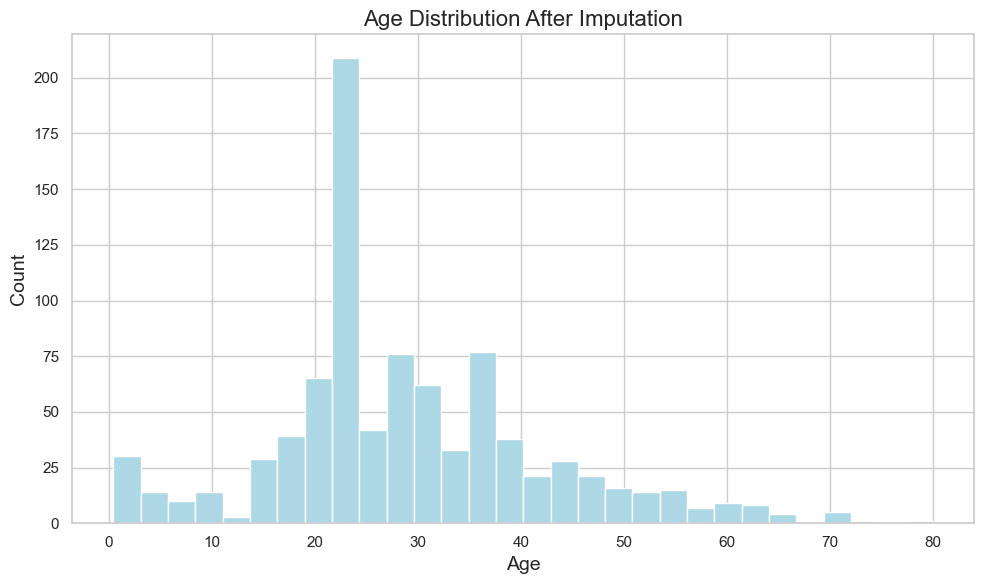

In [24]:
# Visualize Age distribution after imputation
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(df["Age"], bins=30,color="lightblue", edgecolor="white")
ax.set_title("Age Distribution After Imputation", fontsize=16)
ax.set_xlabel("Age", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
plt.tight_layout()
plt.show()


## 2.3 Embarked — Fill with Mode

In [25]:
# Check for missing values
print(f"Missing Embarked values: {df['Embarked'].isnull().sum()}")
print(f"Mode of Embarked: {df['Embarked'].mode()[0]}")

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print(f"Missing Embarked values after imputation: {df['Embarked'].isnull().sum()}")

Missing Embarked values: 2
Mode of Embarked: S
Missing Embarked values after imputation: 0


In [26]:
# Confirm all missing values have been handled
print("\nFinal missing values in each column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")



Final missing values in each column:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

Total missing: 0


## 3. Feature Engineering
Let's create new features that capture patterns we discovered during EDA.

# 3.1 Family Size and IsAlone

In [27]:
# Family Size

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# isAlone

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print(f"Number of passengers traveling alone: {df['IsAlone'].sum()} ({df['IsAlone'].mean()*100:.2f}%)")
print(f"Number of passengers with family: {df.shape[0] - df['IsAlone'].sum()} ({(1-df['IsAlone'].mean())*100:.2f}%)")

print(f"\nSurvival rate — Alone: {df[df['IsAlone']==1]['Survived'].mean():.2%}")
print(f"Survival rate — With Family: {df[df['IsAlone']==0]['Survived'].mean():.2%}")


Number of passengers traveling alone: 537 (60.27%)
Number of passengers with family: 354 (39.73%)

Survival rate — Alone: 30.35%
Survival rate — With Family: 50.56%


Passagiere mit Familie überlebten etwa 1,67-mal so häufig wie allein reisende Passagiere.

50,56 / 30,35 ≈ 1,67


## 3.2 Age Groups

In [28]:
# Binning Age into categories
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 80], labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

print("Age group distribution:")
print(df["AgeGroup"].value_counts().sort_index())
print("\nSurvival rate by Age Group:")
print(df.groupby("AgeGroup")["Survived"].mean())

Age group distribution:
AgeGroup
Child           69
Teen            70
Young Adult    505
Adult          225
Senior          22
Name: count, dtype: int64

Survival rate by Age Group:
AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.346535
Adult          0.408889
Senior         0.227273
Name: Survived, dtype: float64


C:\Users\Gian\AppData\Local\Temp\ipykernel_15408\400446538.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("AgeGroup")["Survived"].mean())


# 3.3 Fare Bins

In [29]:
# Bin fare into quartiles
df["FareBin"] = pd.qcut(
    df["Fare"], q=4, labels=["Low", "Medium", "High", "Very High"]
)

print("Survival rate by Fare Bin:")
print(df.groupby("FareBin")["Survived"].mean())

Survival rate by Fare Bin:
FareBin
Low          0.197309
Medium       0.303571
High         0.454955
Very High    0.581081
Name: Survived, dtype: float64


C:\Users\Gian\AppData\Local\Temp\ipykernel_15408\28673781.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("FareBin")["Survived"].mean())


# 4. Encode Categorical Variables

In [30]:
# View current dtypes
print("Current columns and types:")
print(df.dtypes)
print(f"\nShape: {df.shape}")

Current columns and types:
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
HasCabin          int64
FamilySize        int64
IsAlone           int64
AgeGroup       category
FareBin        category
dtype: object

Shape: (891, 16)


In [31]:
# Encode Sex
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encode Embarked, AgeGroup and FareBin
df = pd.get_dummies(df, columns=["Embarked", "AgeGroup", "FareBin"], drop_first=True, dtype=int)

print(f"Shape after encoding: {df.shape}")
df.head()

Shape after encoding: (891, 22)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,IsAlone,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,0,0,1,0,1,0,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,0,0,0,0,0,1,0,0,0,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,1,0,1,0,1,0,0,1,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,0,0,1,0,1,0,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,1,0,1,0,1,0,0,1,0,0


# 5. Drop Unnecessary Columns

In [32]:
# Drop columns not useful for modeling
drop_cols = ["PassengerId", "Name", "Ticket"]
df = df.drop(columns=drop_cols)

print(f"Final shape: {df.shape}")
print(f"\nFinal columns:")
print(df.columns.tolist())

Final shape: (891, 19)

Final columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareBin_Medium', 'FareBin_High', 'FareBin_Very High']


In [33]:
# Final check
print("Missing values:")
print(df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes)

Missing values:
0

Data types:
Survived                  int64
Pclass                    int64
Sex                       int64
Age                     float64
SibSp                     int64
Parch                     int64
Fare                    float64
HasCabin                  int64
FamilySize                int64
IsAlone                   int64
Embarked_Q                int64
Embarked_S                int64
AgeGroup_Teen             int64
AgeGroup_Young Adult      int64
AgeGroup_Adult            int64
AgeGroup_Senior           int64
FareBin_Medium            int64
FareBin_High              int64
FareBin_Very High         int64
dtype: object


# 6. Save Cleaned Data

In [34]:
# Save the cleaned and engineered dataset
df.to_csv("data/titanic_cleaned.csv", index=False)
print("Cleaned dataset saved to data/titanic_cleaned.csv")
print(f"Final shape: {df.shape}")
df.head()

Cleaned dataset saved to data/titanic_cleaned.csv
Final shape: (891, 19)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,0,3,0,22.0,1,0,7.2500,0,2,0,0,1,0,1,0,0,0,0,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,0,0,0,0,1,0,0,0,1
2,1,3,1,26.0,0,0,7.9250,0,1,1,0,1,0,1,0,0,1,0,0
3,1,1,1,35.0,1,0,53.1000,1,2,0,0,1,0,1,0,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,1,1,0,1,0,1,0,0,1,0,0


# 7. Summary

| Schritt        | Aktion                                                                                        |
| -------------- | --------------------------------------------------------------------------------------------- |
| **Cabin**      | Eine neue Spalte **HasCabin** erstellt und danach die ursprüngliche **Cabin**-Spalte entfernt |
| **Age**        | Fehlende Alterswerte mit dem Gruppen-Median basierend auf **Pclass** und **Sex** ersetzt      |
| **Embarked**   | 2 fehlende Werte mit dem häufigsten Wert, also **S**, gefüllt                                 |
| **FamilySize** | Aus **SibSp + Parch + 1** erstellt                                                            |
| **IsAlone**    | Binäre Spalte für allein reisende Passagiere erstellt                                         |
| **AgeGroup**   | Alter in 5 Altersgruppen eingeteilt                                                           |
| **FareBin**    | Ticketpreise in Quartile eingeteilt                                                           |
| **Encoding**   | **Sex** label-encodiert und kategoriale Variablen per One-Hot-Encoding umgewandelt            |
| **Dropped**    | **PassengerId**, **Name** und **Ticket** entfernt, da sie für das Modell nicht nützlich sind  |


